In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    try:
        plt.style.use('seaborn-whitegrid')
    except OSError:
        plt.style.use('ggplot')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.20.0
GPU disponible: []


In [ ]:
# Cargar el dataset
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('train_revised.csv')
df.head()

# df = pd.read_csv('nairobi/train_revised.csv')
# print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")
# df.head()

Mounted at /content/drive


,ride_id,seat_number,payment_method,payment_receipt,travel_date,travel_time,travel_from,travel_to,car_type,max_capacity
0,1442,15A,Mpesa,UZUEHCBUSO,17-10-17,7:15,Migori,Nairobi,Bus,49
1,5437,14A,Mpesa,TIHLBUSGTE,19-11-17,7:12,Migori,Nairobi,Bus,49
2,5710,8B,Mpesa,EQX8Q5G19O,26-11-17,7:05,Keroka,Nairobi,Bus,49
3,5777,19A,Mpesa,SGP18CL0ME,27-11-17,7:10,Homa Bay,Nairobi,Bus,49
4,5778,11A,Mpesa,BM97HFRGL9,27-11-17,7:12,Migori,Nairobi,Bus,49


In [ ]:
print(f"Shape: {df.shape}")
print(f"\nTipos de datos:\n{df.dtypes}")
print(f"\nValores nulos: {df.isnull().sum().sum()}")
print(f"\n=== Rutas de origen ===")
print(df['travel_from'].value_counts())
print(f"\nTotal rutas: {df['travel_from'].nunique()}")
print(f"\n=== Tipos de vehiculo ===")
print(df['car_type'].value_counts())

Shape: (51645, 10)

Tipos de datos:
ride_id             int64
seat_number        object
payment_method     object
payment_receipt    object
travel_date        object
travel_time        object
travel_from        object
travel_to          object
car_type           object
max_capacity        int64
dtype: object

Valores nulos: 0

=== Rutas de origen ===
travel_from
Kisii        22607
Migori        7027
Homa Bay      6304
Sirare        4449
Rongo         3928
Kehancha      1909
Awendo        1788
Kijauri       1031
Keroka         988
Nyachenge      512
Rodi           405
Mbita          378
Ndhiwa         236
Sori            55
Keumbu          22
Oyugis           5
Kendu Bay        1
Name: count, dtype: int64

Total rutas: 17

=== Tipos de vehiculo ===
car_type
Bus        31985
shuttle    19660
Name: count, dtype: int64


## Paso 3: Preprocesamiento — Construir la Serie de Tiempo

Cada fila = un ticket vendido. Transformamos a serie de tiempo:
1. `travel_date` → datetime
2. Agrupar por fecha + ruta → demanda diaria
3. Rellenar dias sin datos con 0
4. Agregar features temporales (dia de semana, mes)

In [ ]:
# Convertir fecha
df['travel_date'] = pd.to_datetime(df['travel_date'], format='%d-%m-%y')
print(f"Rango de fechas: {df['travel_date'].min()} a {df['travel_date'].max()}")
print(f"Total dias: {(df['travel_date'].max() - df['travel_date'].min()).days + 1}")

# Agrupar por fecha y ruta
demanda = df.groupby(['travel_date', 'travel_from']).size().reset_index(name='demanda')

# Rango completo de fechas x rutas
fecha_min, fecha_max = demanda['travel_date'].min(), demanda['travel_date'].max()
rango_fechas = pd.date_range(start=fecha_min, end=fecha_max, freq='D')
rutas = demanda['travel_from'].unique()

idx = pd.MultiIndex.from_product([rango_fechas, rutas], names=['travel_date', 'travel_from'])
demanda = demanda.set_index(['travel_date', 'travel_from']).reindex(idx, fill_value=0).reset_index()

# Features temporales
demanda['dia_semana'] = demanda['travel_date'].dt.dayofweek
demanda['mes'] = demanda['travel_date'].dt.month
demanda['dia_mes'] = demanda['travel_date'].dt.day
demanda['nombre_dia'] = demanda['travel_date'].dt.day_name()

# Demanda total
demanda_total = demanda.groupby('travel_date')['demanda'].sum().reset_index()
demanda_total.columns = ['travel_date', 'demanda_total']

# Filtrar rutas con demanda significativa (>500 tickets totales)
UMBRAL_TICKETS = 500
demanda_por_ruta = demanda.groupby('travel_from')['demanda'].sum().sort_values(ascending=False)
rutas_modelo = demanda_por_ruta[demanda_por_ruta > UMBRAL_TICKETS].index.tolist()
demanda_modelo = demanda[demanda['travel_from'].isin(rutas_modelo)].copy()

print(f"\nSerie construida: {demanda.shape}")
print(f"Umbral: >{UMBRAL_TICKETS} tickets totales")
print(f"Rutas seleccionadas ({len(rutas_modelo)}): {rutas_modelo}")

# Mostrar rutas eliminadas
rutas_eliminadas = demanda_por_ruta[(demanda_por_ruta > 0) & (demanda_por_ruta <= UMBRAL_TICKETS)]
print(f"\nRutas eliminadas ({len(rutas_eliminadas)}):")
for ruta, total in rutas_eliminadas.items():
    promedio = total / 186
    print(f"  {ruta}: {total} tickets totales ({promedio:.1f}/dia promedio)")

print(f"\nDatos para modelar: {demanda_modelo.shape}")
demanda_modelo.head()

Rango de fechas: 2017-10-17 00:00:00 a 2018-04-20 00:00:00
Total dias: 186

Serie construida: (3162, 7)
Umbral: >500 tickets totales
Rutas seleccionadas (10): ['Kisii', 'Migori', 'Homa Bay', 'Sirare', 'Rongo', 'Kehancha', 'Awendo', 'Kijauri', 'Keroka', 'Nyachenge']

Rutas eliminadas (7):
  Rodi: 405 tickets totales (2.2/dia promedio)
  Mbita: 378 tickets totales (2.0/dia promedio)
  Ndhiwa: 236 tickets totales (1.3/dia promedio)
  Sori: 55 tickets totales (0.3/dia promedio)
  Keumbu: 22 tickets totales (0.1/dia promedio)
  Oyugis: 5 tickets totales (0.0/dia promedio)
  Kendu Bay: 1 tickets totales (0.0/dia promedio)

Datos para modelar: (1860, 7)


,travel_date,travel_from,demanda,dia_semana,mes,dia_mes,nombre_dia
0,2017-10-17,Migori,1,1,10,17,Tuesday
1,2017-10-17,Kisii,0,1,10,17,Tuesday
2,2017-10-17,Keroka,0,1,10,17,Tuesday
3,2017-10-17,Homa Bay,0,1,10,17,Tuesday
5,2017-10-17,Rongo,0,1,10,17,Tuesday


## Paso 4: Analisis Exploratorio de Datos (EDA)

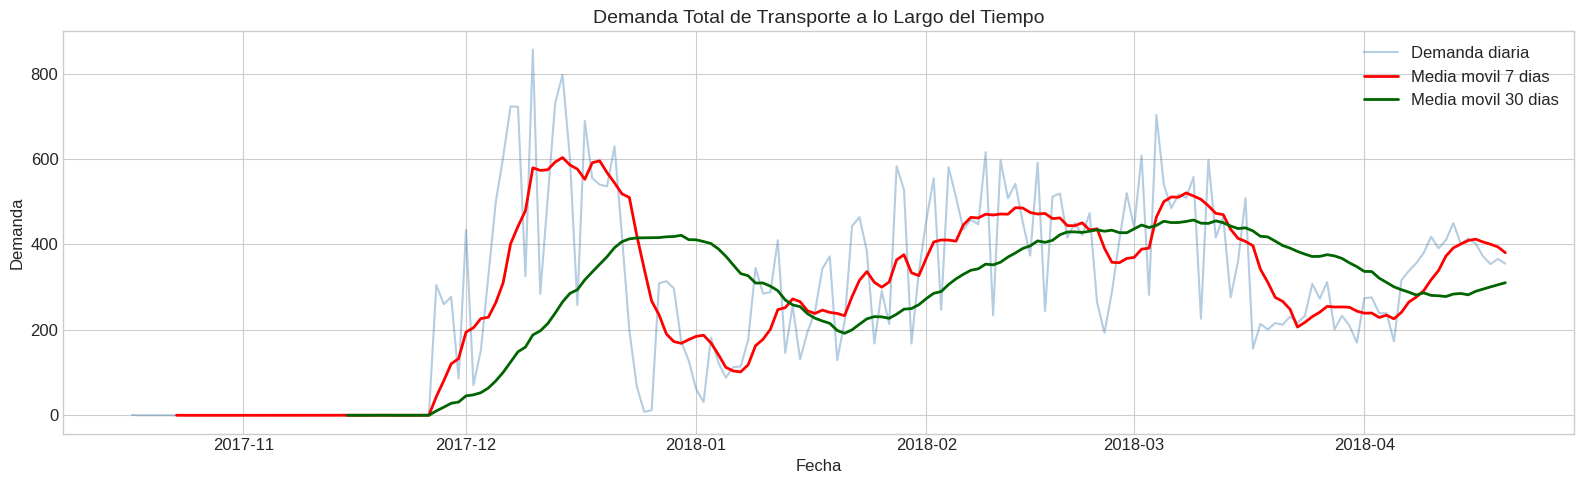

In [ ]:
# 4.1 Demanda total con medias moviles
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(demanda_total['travel_date'], demanda_total['demanda_total'], alpha=0.4, label='Demanda diaria', color='steelblue')
ax.plot(demanda_total['travel_date'], demanda_total['demanda_total'].rolling(7).mean(),
        color='red', linewidth=2, label='Media movil 7 dias')
ax.plot(demanda_total['travel_date'], demanda_total['demanda_total'].rolling(30).mean(),
        color='darkgreen', linewidth=2, label='Media movil 30 dias')
ax.set_title('Demanda Total de Transporte a lo Largo del Tiempo', fontsize=14)
ax.set_xlabel('Fecha'); ax.set_ylabel('Demanda')
ax.legend(); plt.tight_layout(); plt.show()

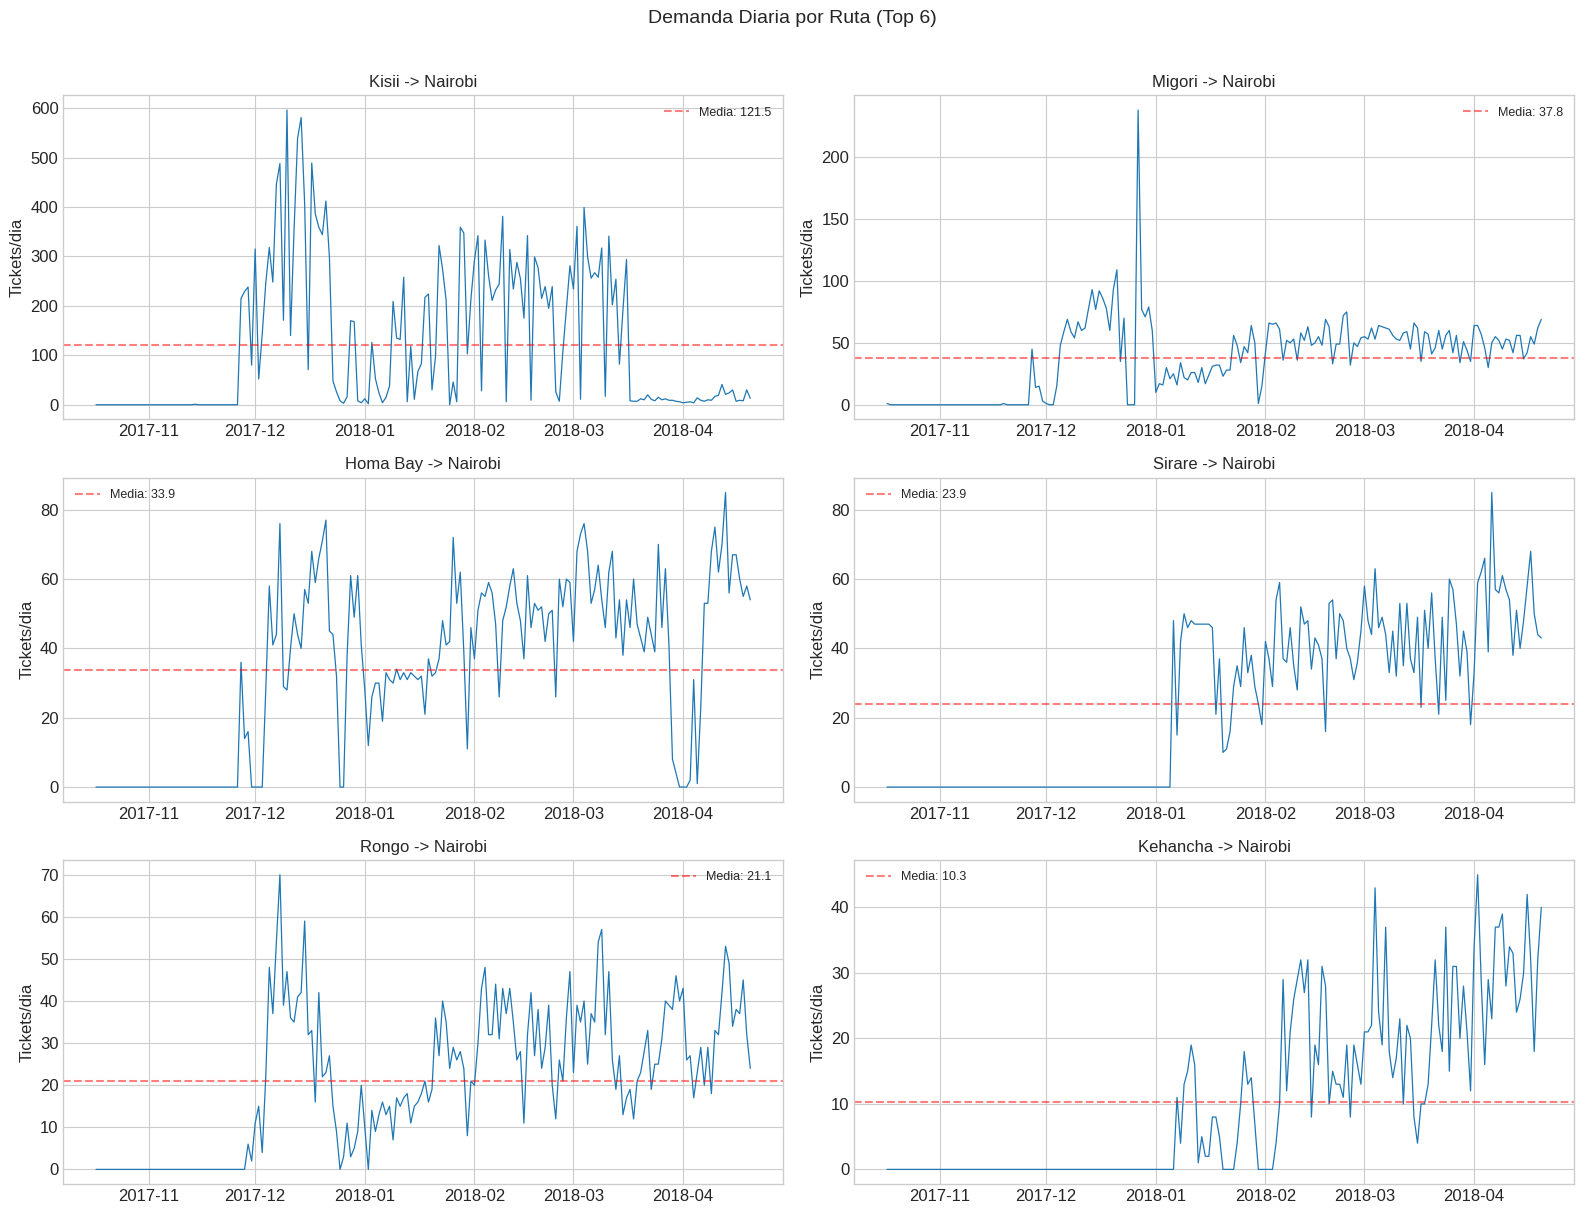

In [ ]:
# 4.2 Demanda por ruta (Top 6)
top_rutas = demanda.groupby('travel_from')['demanda'].sum().nlargest(6).index.tolist()
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
for i, ruta in enumerate(top_rutas):
    ax = axes.flatten()[i]
    datos_ruta = demanda[demanda['travel_from'] == ruta]
    ax.plot(datos_ruta['travel_date'], datos_ruta['demanda'], linewidth=0.9)
    ax.set_title(f'{ruta} -> Nairobi', fontsize=12)
    ax.set_ylabel('Tickets/dia')
    media = datos_ruta['demanda'].mean()
    ax.axhline(y=media, color='red', linestyle='--', alpha=0.5, label=f'Media: {media:.1f}')
    ax.legend(fontsize=9)
plt.suptitle('Demanda Diaria por Ruta (Top 6)', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

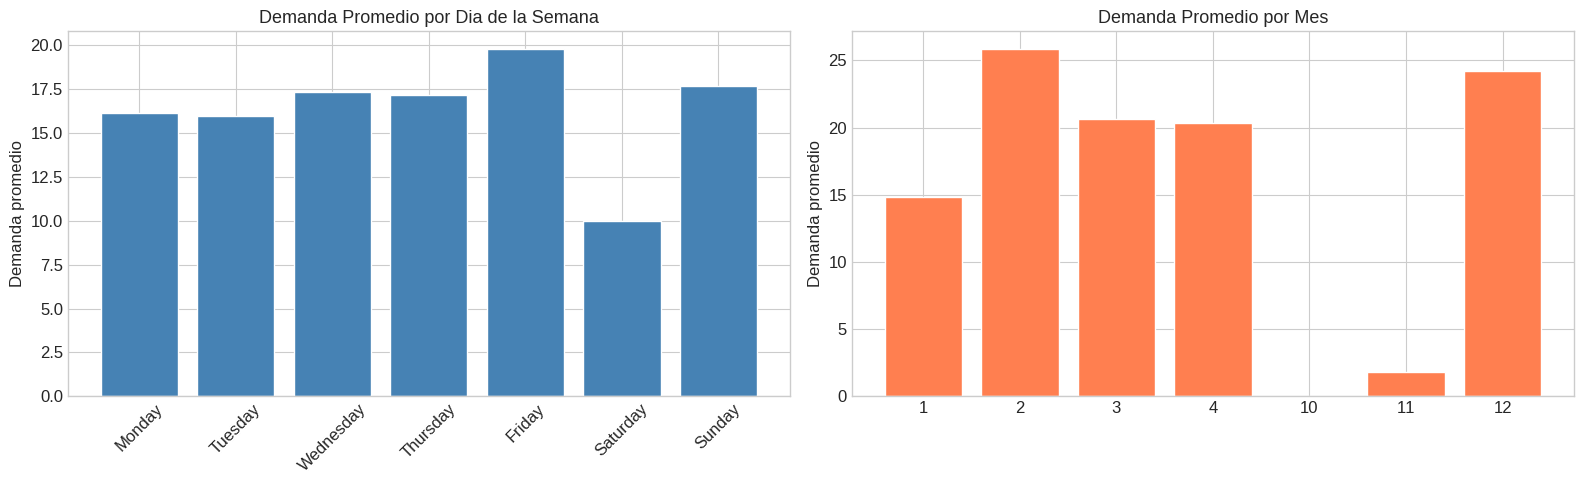

In [ ]:
# 4.3 Estacionalidad semanal y mensual
dias_orden = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
demanda_dia = demanda.groupby('nombre_dia')['demanda'].mean().reindex(dias_orden)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(demanda_dia.index, demanda_dia.values, color='steelblue', edgecolor='white')
axes[0].set_title('Demanda Promedio por Dia de la Semana', fontsize=13)
axes[0].set_ylabel('Demanda promedio'); axes[0].tick_params(axis='x', rotation=45)

demanda_mes = demanda.groupby('mes')['demanda'].mean()
axes[1].bar(demanda_mes.index.astype(str), demanda_mes.values, color='coral', edgecolor='white')
axes[1].set_title('Demanda Promedio por Mes', fontsize=13)
axes[1].set_ylabel('Demanda promedio')
plt.tight_layout(); plt.show()

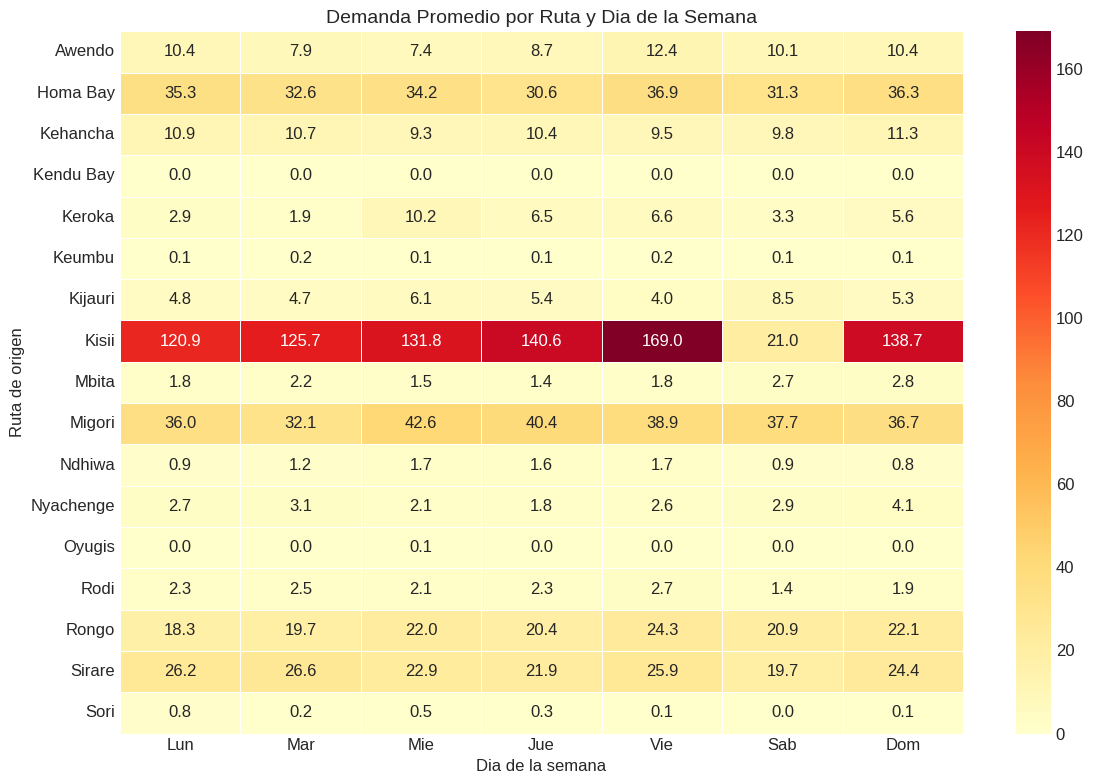

In [ ]:
# 4.4 Heatmap: Demanda promedio por ruta y dia de semana
pivot_heatmap = demanda.pivot_table(values='demanda', index='travel_from', columns='dia_semana', aggfunc='mean')
pivot_heatmap.columns = ['Lun', 'Mar', 'Mie', 'Jue', 'Vie', 'Sab', 'Dom']

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(pivot_heatmap, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Demanda Promedio por Ruta y Dia de la Semana', fontsize=14)
ax.set_ylabel('Ruta de origen'); ax.set_xlabel('Dia de la semana')
plt.tight_layout(); plt.show()

## Paso 5: Preparacion de Datos — Features Tabulares

**Cambio de enfoque respecto al modelo LSTM anterior:**
- En vez de pasar ventanas crudas a una LSTM, **calculamos features agregados** por cada (dia, ruta)
- **Log-transform** `log(1+demanda)` para estabilizar la varianza (especialmente en rutas de alto volumen como Kisii)
- **Features de lag:** demanda de los ultimos 1-7 dias
- **Features de ventana:** media movil 7d, media movil 14d, desviacion estandar 7d
- **Features ciclicos:** dia de semana (sin/cos) + ruta codificada
- **Modelo Dense (MLP)** en vez de LSTM → menos parametros, mas robusto con pocos datos

In [ ]:
# Log-transform para estabilizar varianza
demanda_modelo['demanda_log'] = np.log1p(demanda_modelo['demanda'])

# Normalizar demanda_log por ruta (cada ruta tiene su propio scaler)
scalers = {}
demanda_modelo['demanda_norm'] = 0.0

for ruta in rutas_modelo:
    mask = demanda_modelo['travel_from'] == ruta
    scaler = MinMaxScaler(feature_range=(0, 1))
    vals = demanda_modelo.loc[mask, 'demanda_log'].values.astype(float).reshape(-1, 1)
    demanda_modelo.loc[mask, 'demanda_norm'] = scaler.fit_transform(vals).flatten()
    scalers[ruta] = scaler

# Codificar rutas
le_ruta = LabelEncoder()
demanda_modelo['ruta_encoded'] = le_ruta.fit_transform(demanda_modelo['travel_from'])
n_rutas = len(rutas_modelo)
demanda_modelo['ruta_norm'] = demanda_modelo['ruta_encoded'] / (n_rutas - 1)

# Features ciclicos para dia de semana
demanda_modelo['dia_sin'] = np.sin(2 * np.pi * demanda_modelo['dia_semana'] / 7)
demanda_modelo['dia_cos'] = np.cos(2 * np.pi * demanda_modelo['dia_semana'] / 7)

# Crear lag features y rolling features POR RUTA
for ruta in rutas_modelo:
    mask = demanda_modelo['travel_from'] == ruta
    datos_ruta = demanda_modelo.loc[mask].sort_values('travel_date')
    idx = datos_ruta.index
    serie = datos_ruta['demanda_norm']

    # Lags 1-7
    for lag in range(1, 8):
        demanda_modelo.loc[idx, f'lag_{lag}'] = serie.shift(lag).values

    # Rolling stats
    demanda_modelo.loc[idx, 'rolling_mean_7'] = serie.rolling(7).mean().values
    demanda_modelo.loc[idx, 'rolling_mean_14'] = serie.rolling(14).mean().values
    demanda_modelo.loc[idx, 'rolling_std_7'] = serie.rolling(7).std().fillna(0).values

# Eliminar filas con NaN (primeros 14 dias por ruta)
demanda_features = demanda_modelo.dropna().copy()

FEATURE_COLS = ([f'lag_{i}' for i in range(1, 8)]
                + ['rolling_mean_7', 'rolling_mean_14', 'rolling_std_7',
                   'dia_sin', 'dia_cos', 'ruta_norm'])
N_FEATURES = len(FEATURE_COLS)

print(f"Features ({N_FEATURES}): {FEATURE_COLS}")
print(f"Datos con features: {demanda_features.shape[0]} muestras")
print(f"\nEjemplo de features (Kisii):")
demanda_features[demanda_features['travel_from'] == 'Kisii'][['travel_date', 'demanda', 'demanda_norm'] + FEATURE_COLS].head()

Features (13): ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'rolling_mean_7', 'rolling_mean_14', 'rolling_std_7', 'dia_sin', 'dia_cos', 'ruta_norm']
Datos con features: 1730 muestras

Ejemplo de features (Kisii):


,travel_date,demanda,demanda_norm,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,rolling_mean_7,rolling_mean_14,rolling_std_7,dia_sin,dia_cos,ruta_norm
222,2017-10-30,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.000000,0.555556
239,2017-10-31,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.781831,0.623490,0.555556
256,2017-11-01,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.974928,-0.222521,0.555556
273,2017-11-02,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.433884,-0.900969,0.555556
290,2017-11-03,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.433884,-0.900969,0.555556


In [ ]:
# Split temporal POR RUTA (ultimo 20% de cada ruta va a test)
X_train_list, y_train_list = [], []
X_test_list, y_test_list, meta_test = [], [], []

for ruta in rutas_modelo:
    datos_ruta = demanda_features[demanda_features['travel_from'] == ruta].sort_values('travel_date')
    X_ruta = datos_ruta[FEATURE_COLS].values
    y_ruta = datos_ruta['demanda_norm'].values
    fechas = datos_ruta['travel_date'].values

    n = len(X_ruta)
    split = int(n * 0.8)

    X_train_list.append(X_ruta[:split])
    y_train_list.append(y_ruta[:split])
    X_test_list.append(X_ruta[split:])
    y_test_list.append(y_ruta[split:])
    meta_test.extend([(ruta, fechas[j]) for j in range(split, n)])

X_train = np.vstack(X_train_list)
y_train = np.concatenate(y_train_list)
X_test = np.vstack(X_test_list)
y_test = np.concatenate(y_test_list)

print(f"Total muestras: {len(X_train) + len(X_test)}")
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")
print(f"Shape entrada: {X_train.shape} = (muestras, {N_FEATURES} features)")
print(f"\nRutas en test: {len(set(m[0] for m in meta_test))}/{len(rutas_modelo)}")
for ruta in rutas_modelo:
    n_test = sum(1 for m in meta_test if m[0] == ruta)
    if n_test > 0:
        print(f"  {ruta}: {n_test} muestras en test")

Total muestras: 1730
Train: 1380, Test: 350
Shape entrada: (1380, 13) = (muestras, 13 features)

Rutas en test: 10/10
  Kisii: 35 muestras en test
  Migori: 35 muestras en test
  Homa Bay: 35 muestras en test
  Sirare: 35 muestras en test
  Rongo: 35 muestras en test
  Kehancha: 35 muestras en test
  Awendo: 35 muestras en test
  Kijauri: 35 muestras en test
  Keroka: 35 muestras en test
  Nyachenge: 35 muestras en test


## Paso 6: Modelo Dense (MLP) Global

**Arquitectura:** Red densa simple, mas adecuada para datos tabulares con features agregados.
- Dense(32, ReLU) → Dropout(0.2) → Dense(16, ReLU) → Dropout(0.2) → Dense(1)
- Entrada: vector de 13 features (no secuencia temporal)
- Mucho menos parametros que LSTM → mejor ratio muestras/parametros

In [ ]:
# Modelo Dense (MLP)
modelo = Sequential([
    Dense(32, activation='relu', input_shape=(N_FEATURES,)),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(1)
])
modelo.compile(optimizer='adam', loss='mse', metrics=['mae'])
modelo.summary()

total_params = modelo.count_params()
print(f"\nParametros totales: {total_params}")
print(f"Ratio muestras/parametros: {X_train.shape[0]/total_params:.2f}")
print(f"(LSTM anterior: 7,153 params, ratio 0.25)")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 993 (3.88 KB)

 Trainable params: 993 (3.88 KB)

 Non-trainable params: 0 (0.00 B)


Parametros totales: 993
Ratio muestras/parametros: 1.39
(LSTM anterior: 7,153 params, ratio 0.25)


In [ ]:
# Entrenar modelo global
EPOCHS = 150
BATCH_SIZE = 32

callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1)
]

history = modelo.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    callbacks=callbacks,
    verbose=1
)

best_epoch = np.argmin(history.history['val_loss']) + 1
best_val_loss = min(history.history['val_loss'])
print(f"\nMejor val_loss: {best_val_loss:.6f} (epoch {best_epoch})")

Epoch 1/150
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1224 - mae: 0.2662 - val_loss: 0.0310 - val_mae: 0.1385 - learning_rate: 0.0010
Epoch 2/150
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0577 - mae: 0.1767 - val_loss: 0.0313 - val_mae: 0.1456 - learning_rate: 0.0010
Epoch 3/150
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0550 - mae: 0.1744 - val_loss: 0.0326 - val_mae: 0.1501 - learning_rate: 0.0010
Epoch 4/150
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0511 - mae: 0.1655 - val_loss: 0.0323 - val_mae: 0.1500 - learning_rate: 0.0010
Epoch 5/150
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0469 - mae: 0.1582 - val_loss: 0.0325 - val_mae: 0.1510 - learning_rate: 0.0010
Epoch 6/150
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0450 - mae: 0.1553 - val_loss: 0.0301 - val_mae: 0.1439 - learning_rate: 0.0010
Epoch 7/150
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0473 - mae: 0.1575 - val_loss: 0.0314 - val_mae: 0.1470 - learning_rate: 0.0010
Epoch 8/150
4

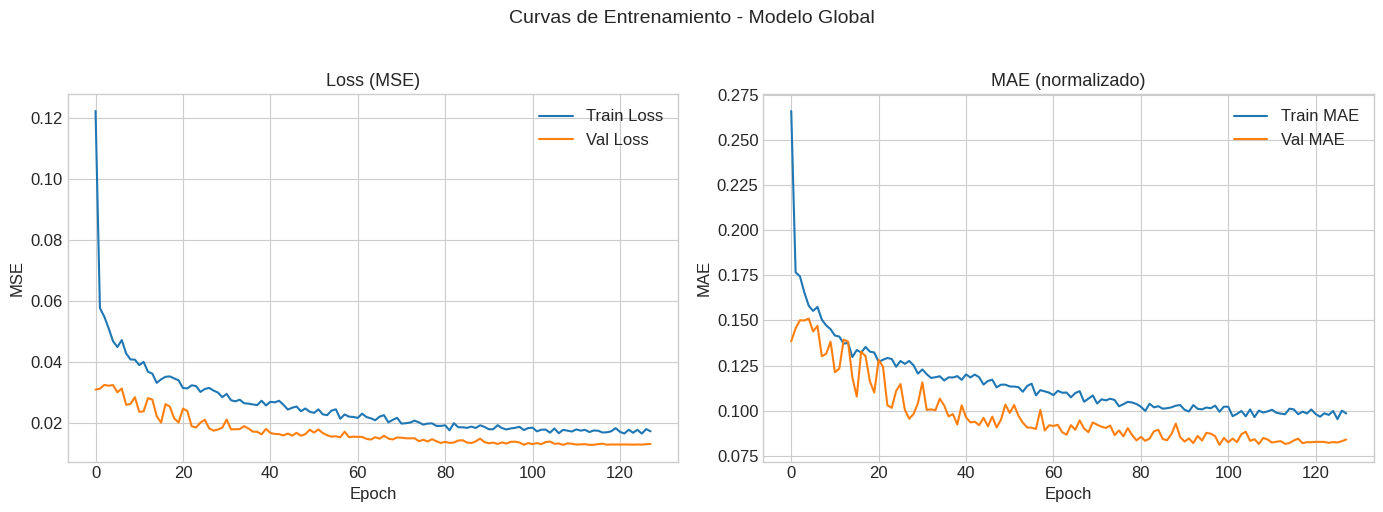

In [ ]:
# Curva de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss (MSE)', fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE')
axes[0].legend()

axes[1].plot(history.history['mae'], label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_title('MAE (normalizado)', fontsize=13)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE')
axes[1].legend()

plt.suptitle('Curvas de Entrenamiento - Modelo Global', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

## Paso 7: Evaluacion del Modelo

Metricas: RMSE, MAE, MAPE — calculadas por ruta para comparar con v1.

In [ ]:
def calcular_mape(y_true, y_pred):
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def inv_transform(valores_norm, scaler):
    """Desnormalizar y deshacer log-transform: expm1(scaler.inverse(norm))"""
    log_vals = scaler.inverse_transform(valores_norm.reshape(-1, 1)).flatten()
    return np.expm1(log_vals)

# Predicciones en test
y_pred_norm = modelo.predict(X_test, verbose=0).flatten()

# Evaluar por ruta
resultados = []
resultados_por_ruta = {}

for ruta in rutas_modelo:
    indices = [i for i, m in enumerate(meta_test) if m[0] == ruta]
    if len(indices) == 0:
        continue

    scaler = scalers[ruta]
    y_pred_ruta = np.maximum(inv_transform(y_pred_norm[indices], scaler), 0)
    y_real_ruta = inv_transform(y_test[indices], scaler)

    rmse = np.sqrt(mean_squared_error(y_real_ruta, y_pred_ruta))
    mae = mean_absolute_error(y_real_ruta, y_pred_ruta)
    mape = calcular_mape(y_real_ruta, y_pred_ruta)

    resultados.append({
        'Ruta': ruta, 'Muestras': len(indices),
        'RMSE': round(rmse, 2), 'MAE': round(mae, 2), 'MAPE (%)': round(mape, 2)
    })
    resultados_por_ruta[ruta] = {'y_real': y_real_ruta, 'y_pred': y_pred_ruta}

df_resultados = pd.DataFrame(resultados)
print("=== Metricas por Ruta (Dense + log-transform + features tabulares) ===\n")
print(df_resultados.to_string(index=False))

total_m = df_resultados['Muestras'].sum()
wmean_rmse = (df_resultados['RMSE'] * df_resultados['Muestras']).sum() / total_m
wmean_mae = (df_resultados['MAE'] * df_resultados['Muestras']).sum() / total_m
mask_mape = df_resultados['MAPE (%)'].notna()
wmean_mape = (df_resultados.loc[mask_mape, 'MAPE (%)'] * df_resultados.loc[mask_mape, 'Muestras']).sum() / df_resultados.loc[mask_mape, 'Muestras'].sum()
print(f"\n--- Promedios ponderados ---")
print(f"RMSE: {wmean_rmse:.2f},  MAE: {wmean_mae:.2f},  MAPE: {wmean_mape:.2f}%")
print(f"\nRutas evaluadas: {len(resultados)}/{len(rutas_modelo)}")

=== Metricas por Ruta (Dense + log-transform + features tabulares) ===

     Ruta  Muestras  RMSE   MAE  MAPE (%)
    Kisii        35 14.37  8.98     82.11
   Migori        35 11.33  9.14     21.18
 Homa Bay        35 19.78 13.66    112.59
   Sirare        35 13.59 10.09     20.59
    Rongo        35  8.73  6.85     22.90
 Kehancha        35  9.41  7.28     25.30
   Awendo        35 12.73  9.99     32.25
  Kijauri        35  5.21  4.09     61.25
   Keroka        35  1.24  0.92     42.94
Nyachenge        35  3.33  2.62     51.66

--- Promedios ponderados ---
RMSE: 9.97,  MAE: 7.36,  MAPE: 47.28%

Rutas evaluadas: 10/10


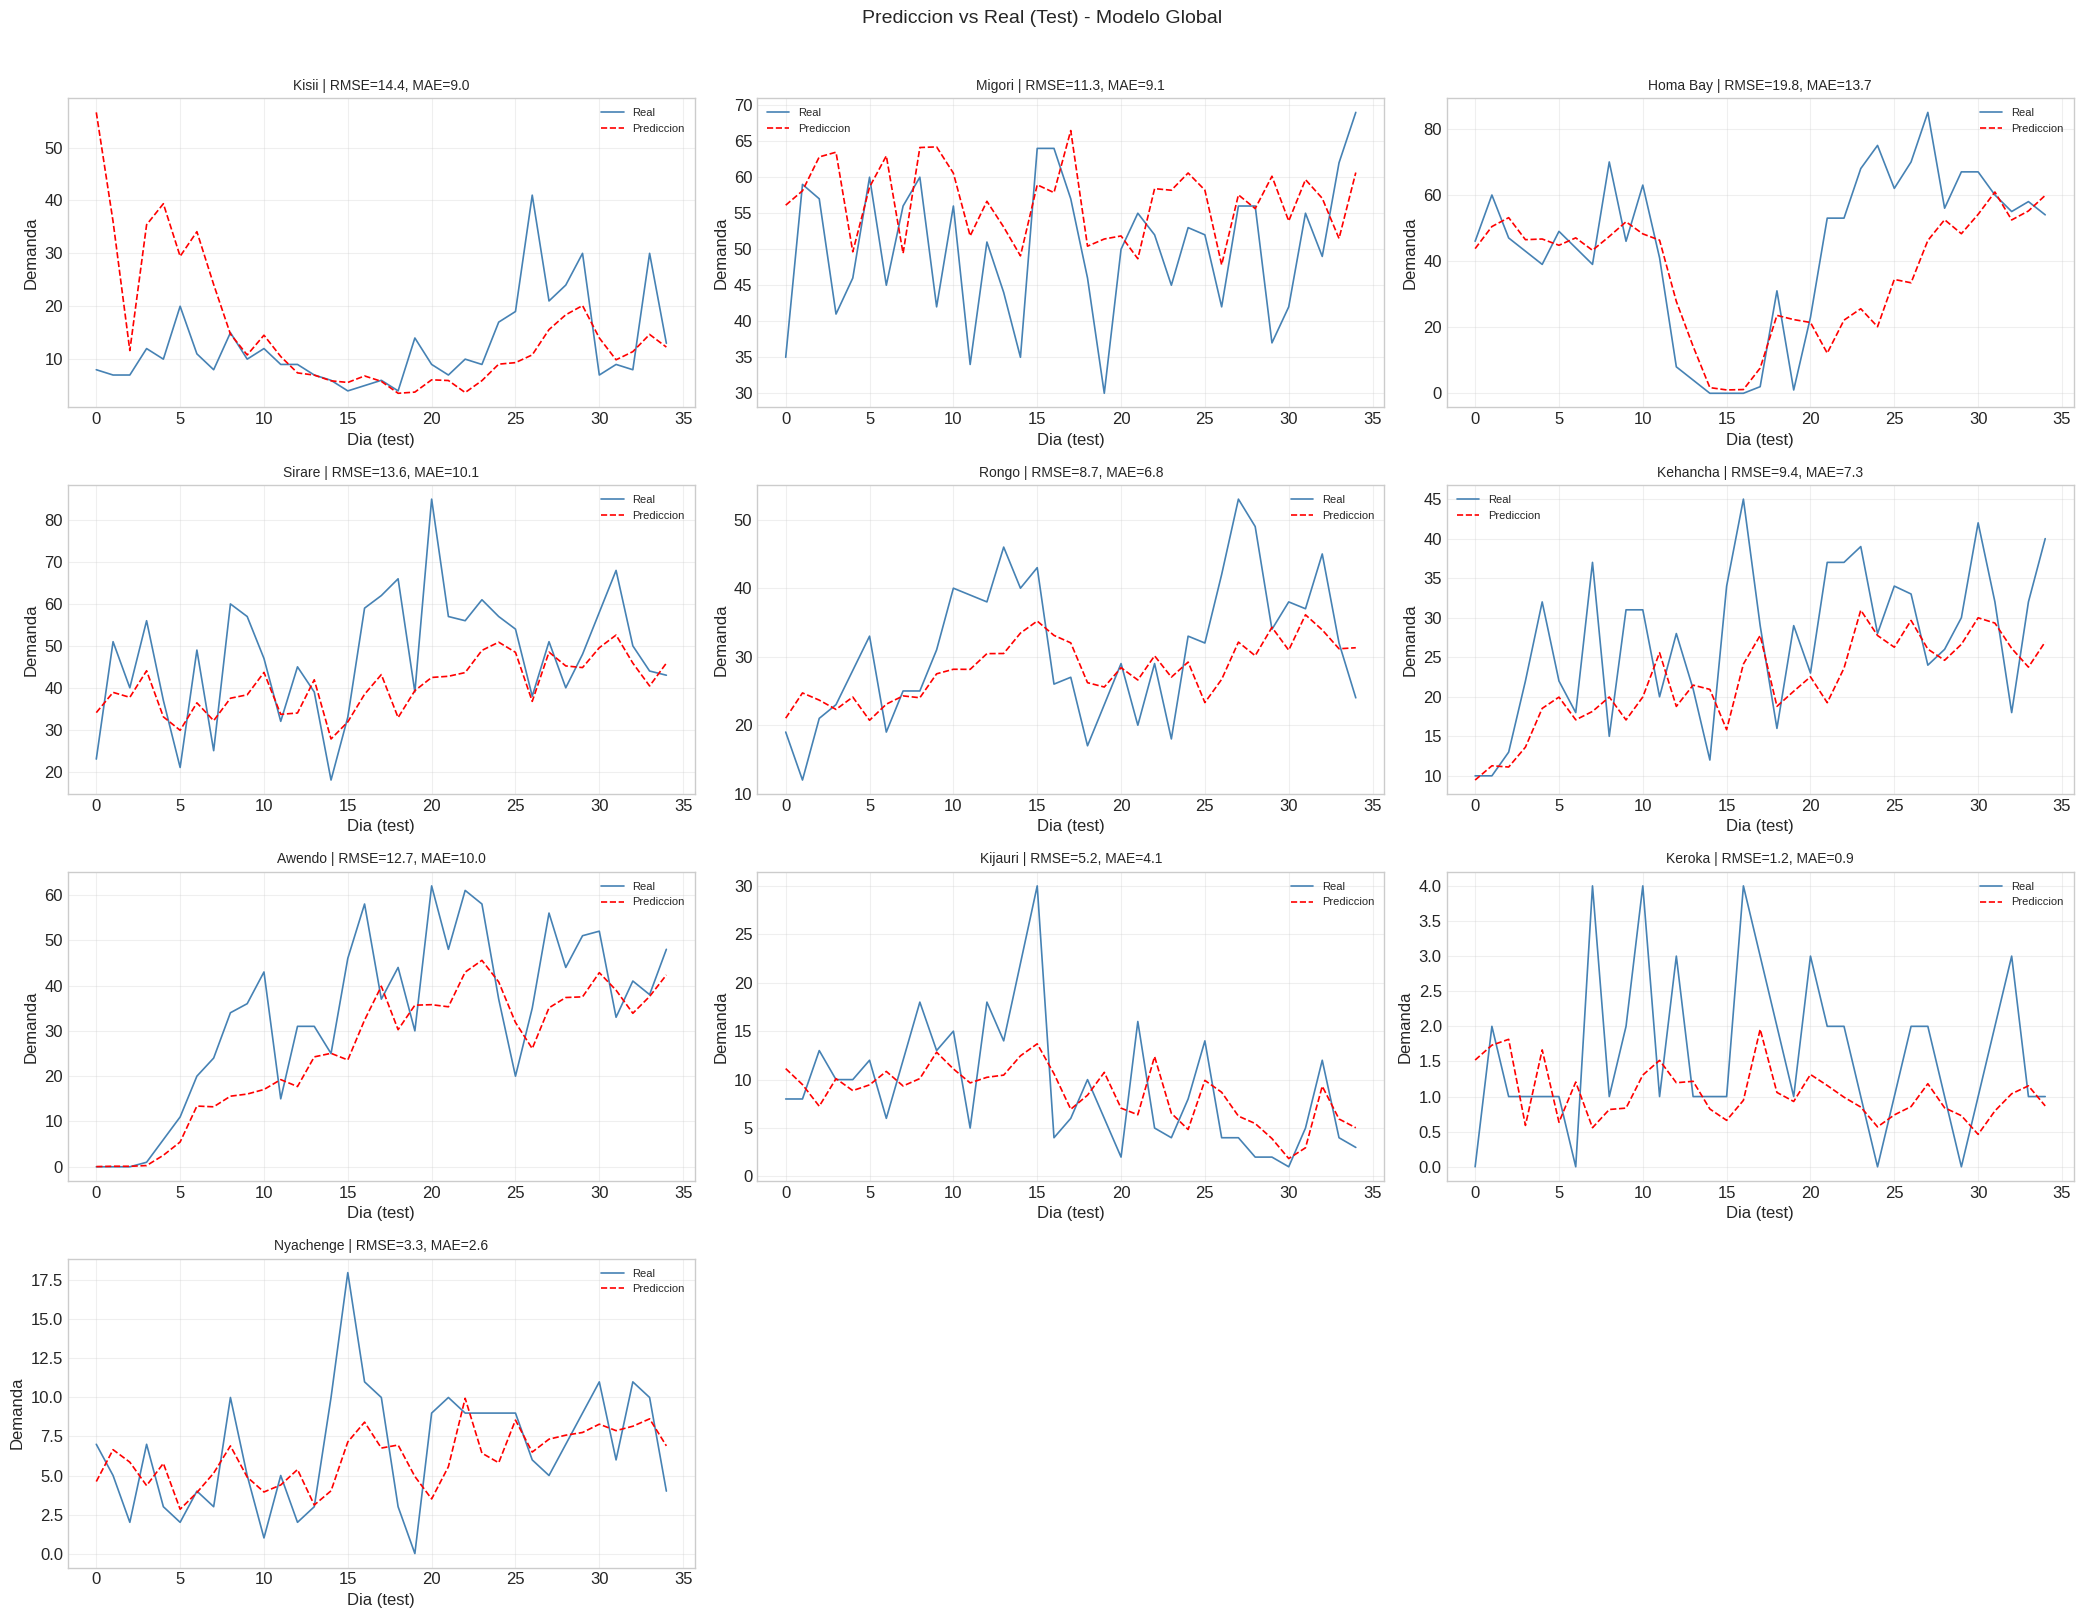

In [ ]:
# Graficas Prediccion vs Real por ruta
rutas_con_datos = [r for r in rutas_modelo if r in resultados_por_ruta]
n = len(rutas_con_datos)
cols = min(3, n)
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 4 * rows))
if n == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, ruta in enumerate(rutas_con_datos):
    ax = axes[i]
    res = resultados_por_ruta[ruta]
    r = next(r for r in resultados if r['Ruta'] == ruta)
    ax.plot(res['y_real'], label='Real', color='steelblue', linewidth=1.2)
    ax.plot(res['y_pred'], label='Prediccion', color='red', linewidth=1.2, linestyle='--')
    ax.set_title(f"{ruta} | RMSE={r['RMSE']:.1f}, MAE={r['MAE']:.1f}", fontsize=10)
    ax.set_xlabel('Dia (test)'); ax.set_ylabel('Demanda')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Prediccion vs Real (Test) - Modelo Global', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

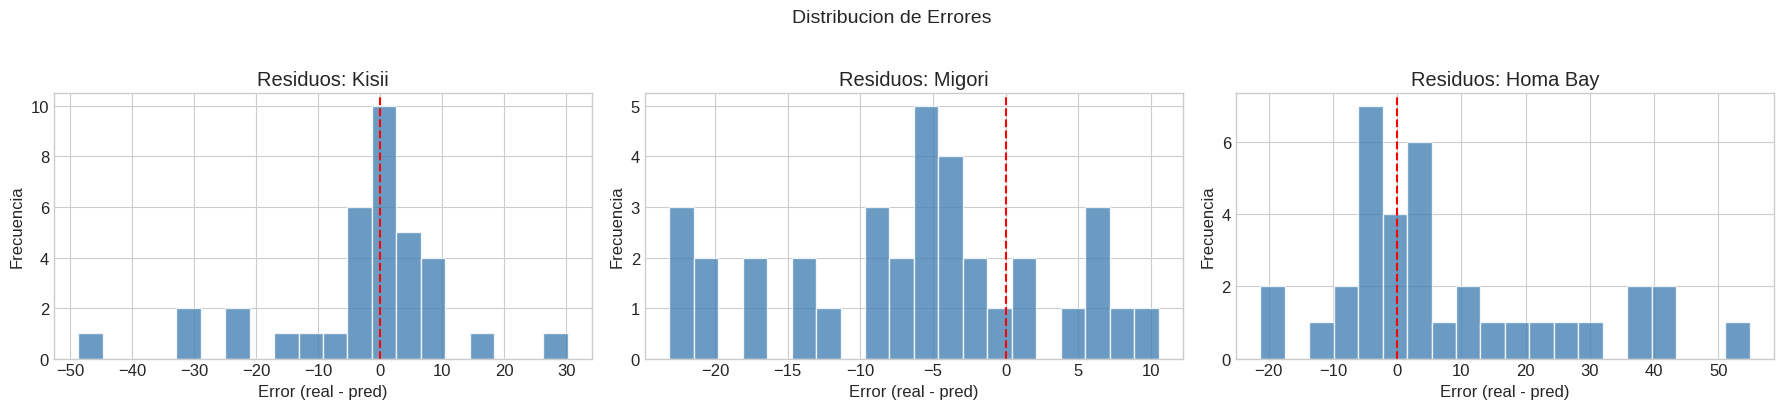

In [ ]:
# Distribucion de residuos (top 3 rutas)
fig, axes = plt.subplots(1, min(3, len(rutas_con_datos)), figsize=(6 * min(3, len(rutas_con_datos)), 4))
if len(rutas_con_datos) == 1:
    axes = [axes]

for i, ruta in enumerate(rutas_con_datos[:3]):
    res = resultados_por_ruta[ruta]
    residuos = res['y_real'] - res['y_pred']
    axes[i].hist(residuos, bins=20, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].axvline(x=0, color='red', linestyle='--')
    axes[i].set_title(f'Residuos: {ruta}')
    axes[i].set_xlabel('Error (real - pred)'); axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribucion de Errores', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

## Paso 8: Prediccion a 30 Dias Futuros

Prediccion recursiva: cada dia predicho se usa como input para el siguiente.
A diferencia de v1, aqui incluimos los features de dia de semana que avanzan correctamente.

In [ ]:
DIAS_FUTURO = 30
ultima_fecha = demanda_modelo['travel_date'].max()
fechas_futuras = pd.date_range(start=ultima_fecha + timedelta(days=1), periods=DIAS_FUTURO, freq='D')

predicciones_futuras = {}

for ruta in rutas_modelo:
    datos_ruta = demanda_modelo[demanda_modelo['travel_from'] == ruta].sort_values('travel_date')
    scaler = scalers[ruta]
    ruta_norm_val = datos_ruta['ruta_norm'].iloc[0]

    # Historial de los ultimos 14 dias (en escala normalizada)
    historia = datos_ruta['demanda_norm'].values[-14:].tolist()

    preds_norm = []
    for dia_idx in range(DIAS_FUTURO):
        fecha = fechas_futuras[dia_idx]
        dia_semana = fecha.dayofweek

        # Construir features tabulares
        lags = [historia[-(i + 1)] for i in range(7)]  # lag_1 a lag_7
        rm7 = np.mean(historia[-7:])
        rm14 = np.mean(historia[-14:])
        rs7 = np.std(historia[-7:])
        dia_sin = np.sin(2 * np.pi * dia_semana / 7)
        dia_cos = np.cos(2 * np.pi * dia_semana / 7)

        features = np.array([lags + [rm7, rm14, rs7, dia_sin, dia_cos, ruta_norm_val]])
        pred = modelo.predict(features, verbose=0)[0, 0]
        preds_norm.append(pred)
        historia.append(pred)

    # Desnormalizar: inverse MinMaxScaler -> expm1 (inverse log1p)
    preds_real = np.maximum(inv_transform(np.array(preds_norm), scaler), 0)
    predicciones_futuras[ruta] = preds_real

# DataFrame de predicciones
df_pred = pd.DataFrame({'Fecha': fechas_futuras})
for ruta in rutas_modelo:
    df_pred[ruta] = predicciones_futuras[ruta].round(1)

print(f"Predicciones: {fechas_futuras[0].strftime('%Y-%m-%d')} a {fechas_futuras[-1].strftime('%Y-%m-%d')}\n")
df_pred

Predicciones: 2018-04-21 a 2018-05-20



,Fecha,Kisii,Migori,Homa Bay,Sirare,Rongo,Kehancha,Awendo,Kijauri,Keroka,Nyachenge
0,2018-04-21,9.9,61.500000,54.200001,42.700001,34.200001,27.400000,40.400002,4.1,0.7,6.7
1,2018-04-22,13.4,58.400002,57.700001,44.200001,32.799999,23.400000,43.900002,4.2,0.6,7.8
2,2018-04-23,8.6,59.900002,60.700001,46.799999,34.700001,27.000000,45.900002,2.6,0.6,9.3
3,2018-04-24,11.2,70.500000,61.299999,52.599998,34.599998,28.299999,40.599998,3.0,0.5,6.8
4,2018-04-25,9.1,60.900002,60.400002,43.400002,36.599998,22.299999,43.099998,8.0,0.6,8.2
5,2018-04-26,12.0,63.900002,61.400002,39.700001,31.600000,24.400000,42.299999,4.9,0.6,8.9
6,2018-04-27,9.0,71.000000,58.099998,42.900002,30.000000,27.299999,45.599998,3.6,0.6,6.9
7,2018-04-28,8.7,66.400002,57.200001,44.099998,34.099998,27.600000,43.799999,3.2,0.4,7.5
8,2018-04-29,9.3,71.800003,58.900002,45.200001,34.700001,25.500000,46.200001,4.6,0.5,8.3
9,2018-04-30,9.3,72.800003,60.099998,46.700001,36.200001,26.400000,47.200001,4.0,0.3,9.4


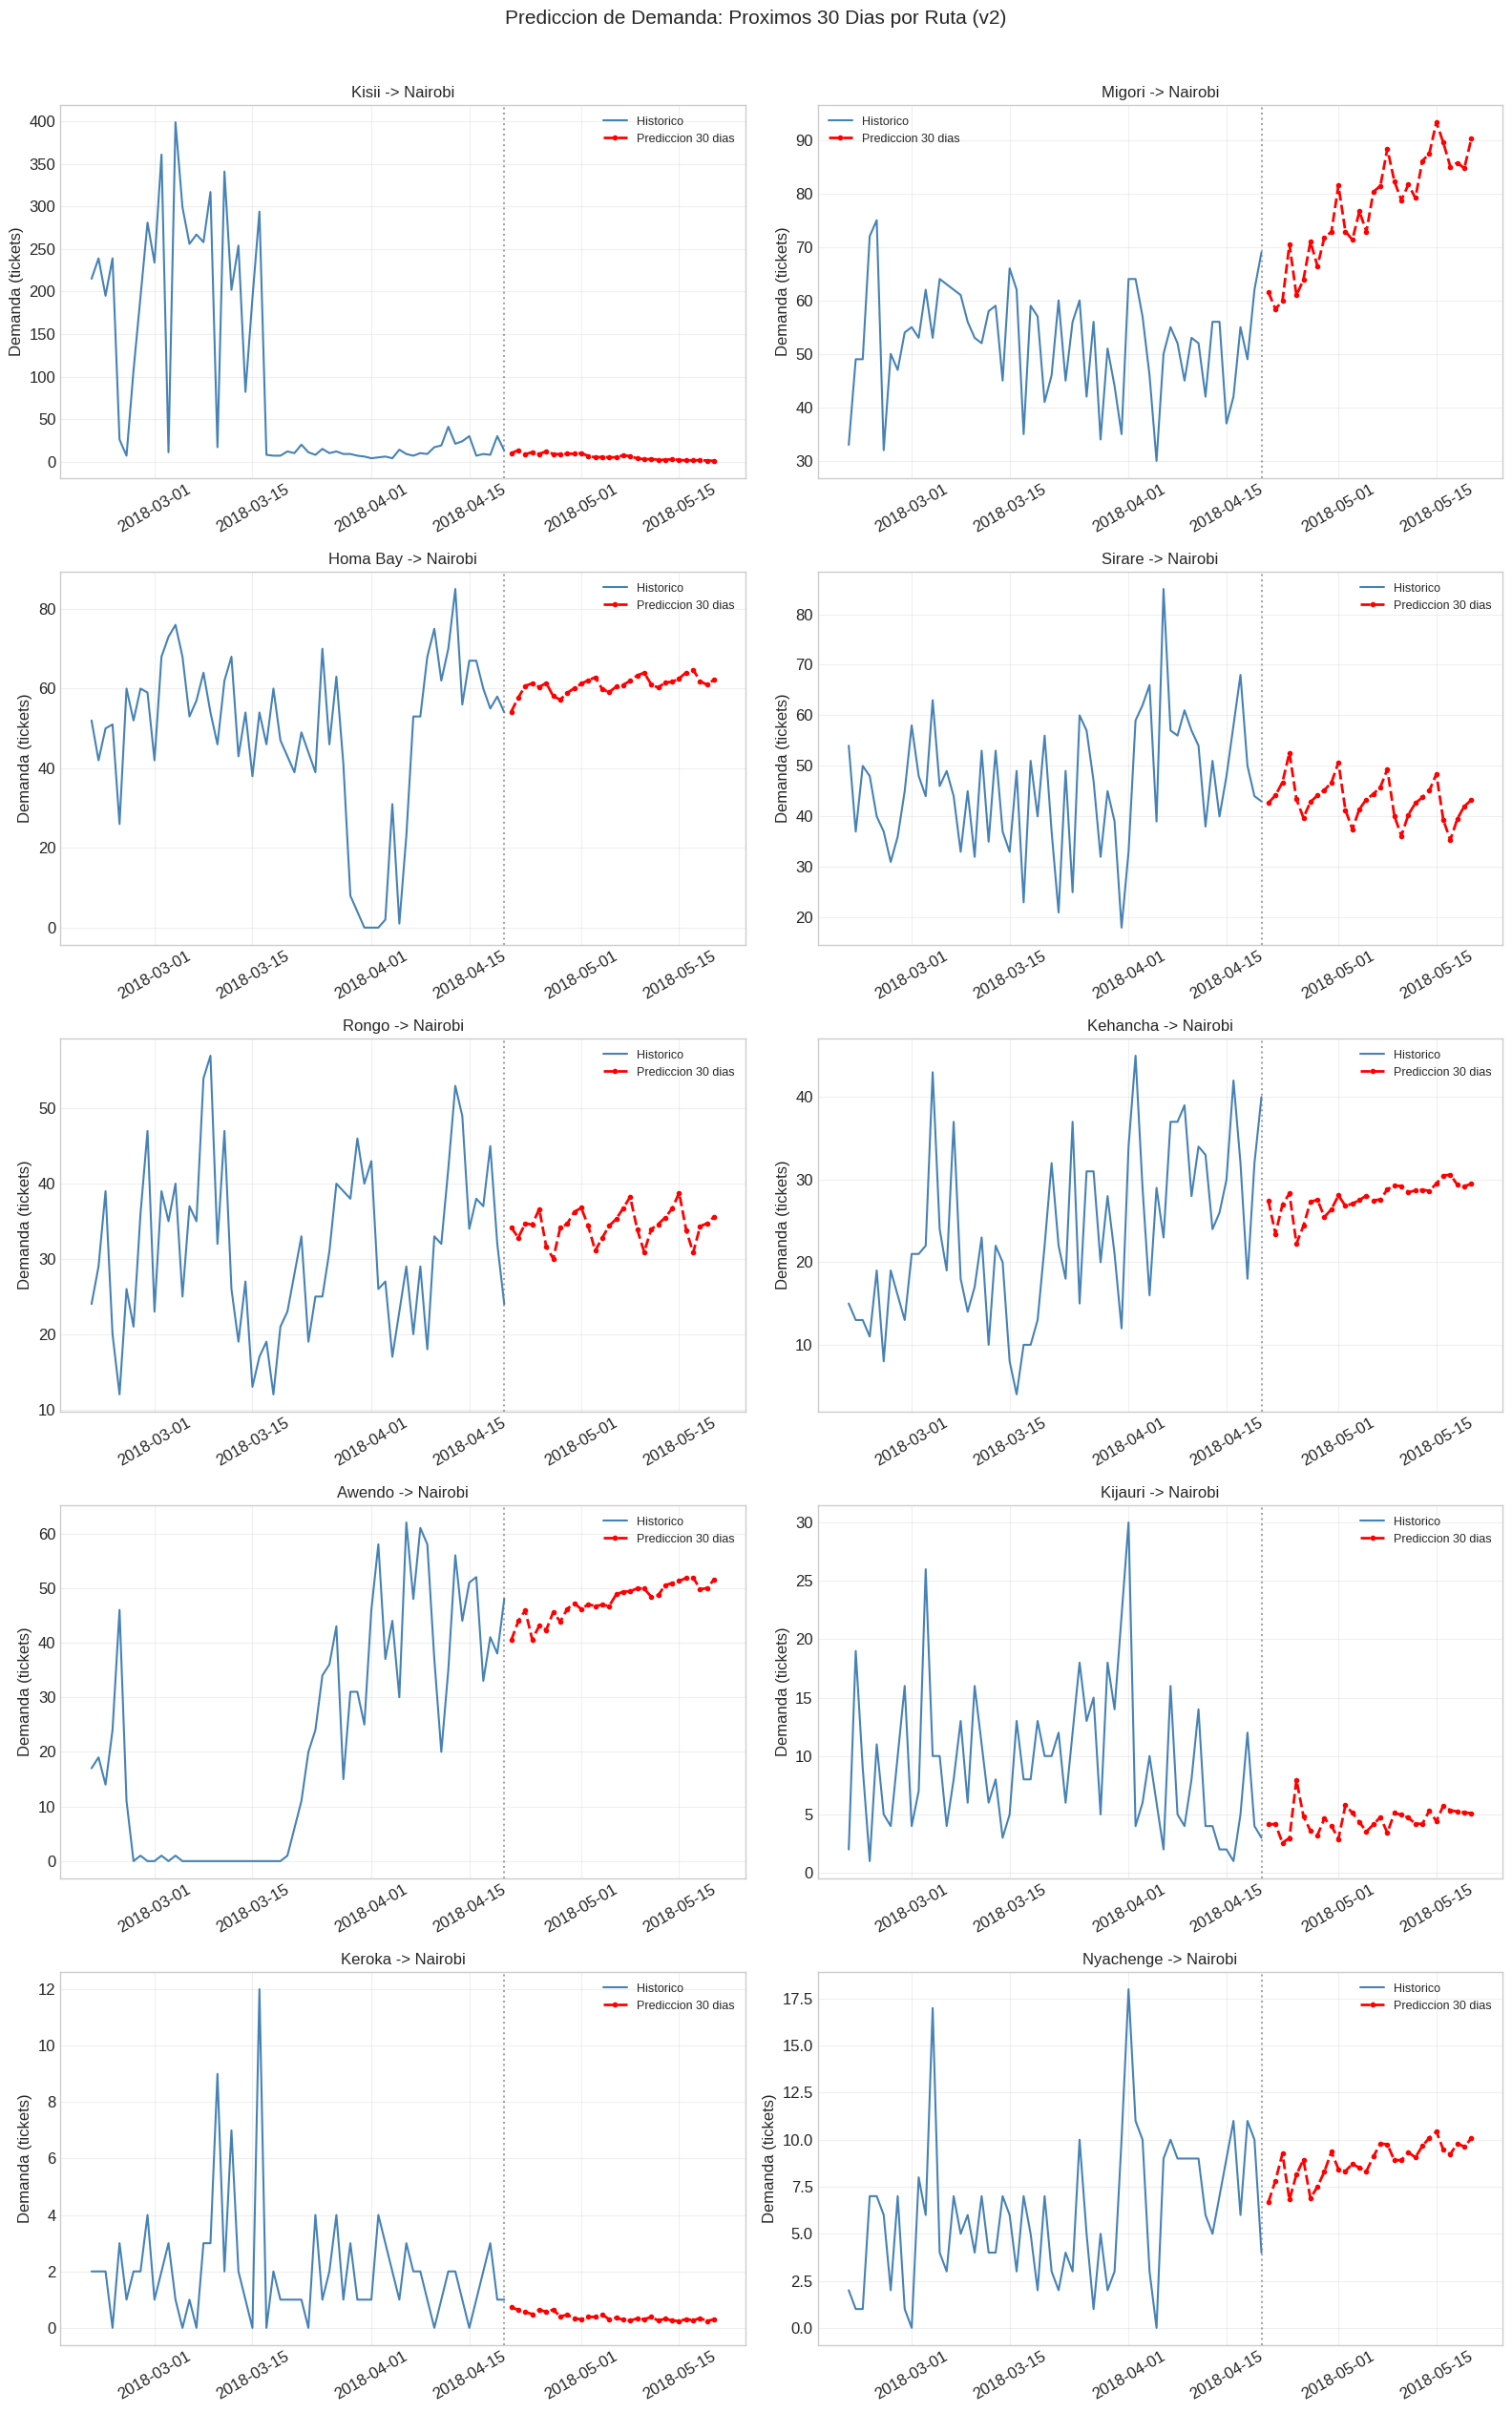

In [ ]:
# Visualizar historico + prediccion futura por ruta
n = len(rutas_modelo)
cols = min(2, n)
rows = (n + cols - 1) // cols
DIAS_HIST = 60

fig, axes = plt.subplots(rows, cols, figsize=(8 * cols, 5 * rows))
if n == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, ruta in enumerate(rutas_modelo):
    ax = axes[i]
    datos_ruta = demanda_modelo[demanda_modelo['travel_from'] == ruta].sort_values('travel_date')
    serie = datos_ruta['demanda'].values

    fechas_hist = pd.date_range(end=ultima_fecha, periods=min(DIAS_HIST, len(serie)), freq='D')
    hist_vals = serie[-len(fechas_hist):]

    ax.plot(fechas_hist, hist_vals, color='steelblue', linewidth=1.5, label='Historico')
    ax.plot(fechas_futuras, predicciones_futuras[ruta], color='red', linewidth=2,
            linestyle='--', marker='o', markersize=3, label='Prediccion 30 dias')
    ax.axvline(x=ultima_fecha, color='gray', linestyle=':', alpha=0.7)
    ax.set_title(f'{ruta} -> Nairobi', fontsize=12)
    ax.set_ylabel('Demanda (tickets)')
    ax.legend(fontsize=9); ax.tick_params(axis='x', rotation=30); ax.grid(True, alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Prediccion de Demanda: Proximos 30 Dias por Ruta (v2)', fontsize=15, y=1.01)
plt.tight_layout(); plt.show()

In [ ]:
# Resumen de predicciones futuras
print("=== Resumen de Predicciones a 30 Dias ===\n")
for ruta in rutas_modelo:
    preds = predicciones_futuras[ruta]
    print(f"{ruta} -> Nairobi:")
    print(f"  Promedio: {preds.mean():.1f} tickets/dia")
    print(f"  Rango: [{preds.min():.1f}, {preds.max():.1f}]")
    print(f"  Total 30 dias: {preds.sum():.0f} tickets")
    print()


=== Resumen de Predicciones a 30 Dias ===

Kisii -> Nairobi:
  Promedio: 5.9 tickets/dia
  Rango: [0.9, 13.4]
  Total 30 dias: 178 tickets

Migori -> Nairobi:
  Promedio: 76.9 tickets/dia
  Rango: [58.4, 93.3]
  Total 30 dias: 2306 tickets

Homa Bay -> Nairobi:
  Promedio: 60.9 tickets/dia
  Rango: [54.2, 64.8]
  Total 30 dias: 1827 tickets

Sirare -> Nairobi:
  Promedio: 43.3 tickets/dia
  Rango: [35.3, 52.6]
  Total 30 dias: 1298 tickets

Rongo -> Nairobi:
  Promedio: 34.4 tickets/dia
  Rango: [30.0, 38.8]
  Total 30 dias: 1033 tickets

Kehancha -> Nairobi:
  Promedio: 27.8 tickets/dia
  Rango: [22.3, 30.6]
  Total 30 dias: 833 tickets

Awendo -> Nairobi:
  Promedio: 47.5 tickets/dia
  Rango: [40.4, 52.0]
  Total 30 dias: 1425 tickets

Kijauri -> Nairobi:
  Promedio: 4.5 tickets/dia
  Rango: [2.6, 8.0]
  Total 30 dias: 136 tickets

Keroka -> Nairobi:
  Promedio: 0.4 tickets/dia
  Rango: [0.2, 0.7]
  Total 30 dias: 12 tickets

Nyachenge -> Nairobi:
  Promedio: 8.8 tickets/dia
  Rango:

## Paso 10: Exportar Modelo para Produccion

Guardamos todos los artefactos necesarios para que el modelo pueda ser cargado desde una aplicacion web (Flask, FastAPI, etc.):

In [ ]:
import joblib
import os
import json

# Crear carpeta de exportacion
EXPORT_DIR = 'modelo_demanda'
os.makedirs(EXPORT_DIR, exist_ok=True)

# 1. Guardar modelo Keras
modelo.save(os.path.join(EXPORT_DIR, 'modelo.keras'))
print("Modelo guardado: modelo.keras")

# 2. Guardar scalers (uno por ruta)
joblib.dump(scalers, os.path.join(EXPORT_DIR, 'scalers.joblib'))
print(f"Scalers guardados: {len(scalers)} rutas")

# 3. Guardar metadata necesaria para reconstruir predicciones
# Historial reciente por ruta (ultimos 14 dias normalizados) para prediccion futura
historiales = {}
for ruta in rutas_modelo:
    datos_ruta = demanda_modelo[demanda_modelo['travel_from'] == ruta].sort_values('travel_date')
    historiales[ruta] = {
        'demanda_norm_14d': datos_ruta['demanda_norm'].values[-14:].tolist(),
        'ruta_norm': float(datos_ruta['ruta_norm'].iloc[0]),
        'ultima_fecha': str(datos_ruta['travel_date'].max().date())
    }

metadata = {
    'rutas': rutas_modelo,
    'feature_cols': FEATURE_COLS,
    'n_features': N_FEATURES,
    'historiales': historiales,
    'umbral_tickets': UMBRAL_TICKETS
}

with open(os.path.join(EXPORT_DIR, 'metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=2)
print("Metadata guardada: metadata.json")

# Resumen de archivos exportados
print(f"\n=== Archivos en '{EXPORT_DIR}/' ===")
for archivo in os.listdir(EXPORT_DIR):
    size = os.path.getsize(os.path.join(EXPORT_DIR, archivo))
    print(f"  {archivo} ({size/1024:.1f} KB)")



Modelo guardado: modelo.keras
Scalers guardados: 10 rutas
Metadata guardada: metadata.json

=== Archivos en 'modelo_demanda/' ===
  modelo.keras (40.8 KB)
  scalers.joblib (3.9 KB)
  metadata.json (5.5 KB)


In [ ]:
# === CODIGO DE EJEMPLO PARA LA WEB (copiar esto) ===


ejemplo_codigo = """
import numpy as np
import json
import joblib
from tensorflow.keras.models import load_model
from datetime import datetime, timedelta

# --- Cargar artefactos ---
modelo = load_model('modelo_demanda/modelo.keras')
scalers = joblib.load('modelo_demanda/scalers.joblib')
with open('modelo_demanda/metadata.json') as f:
    metadata = json.load(f)

def predecir_ruta(ruta, dias=30):
    \"\"\"Predice demanda futura para una ruta especifica.\"\"\"
    if ruta not in metadata['rutas']:
        return {'error': f'Ruta no disponible. Opciones: {metadata["rutas"]}'}

    info = metadata['historiales'][ruta]
    scaler = scalers[ruta]
    historia = info['demanda_norm_14d'].copy()
    ruta_norm = info['ruta_norm']
    ultima_fecha = datetime.strptime(info['ultima_fecha'], '%Y-%m-%d')

    predicciones = []
    for i in range(dias):
        fecha = ultima_fecha + timedelta(days=i+1)
        dia_semana = fecha.weekday()

        # Construir features
        lags = [historia[-(j+1)] for j in range(7)]
        rm7 = np.mean(historia[-7:])
        rm14 = np.mean(historia[-14:])
        rs7 = np.std(historia[-7:])
        dia_sin = np.sin(2 * np.pi * dia_semana / 7)
        dia_cos = np.cos(2 * np.pi * dia_semana / 7)

        features = np.array([lags + [rm7, rm14, rs7, dia_sin, dia_cos, ruta_norm]])
        pred_norm = modelo.predict(features, verbose=0)[0, 0]
        historia.append(pred_norm)

        # Desnormalizar
        log_val = scaler.inverse_transform([[pred_norm]])[0, 0]
        demanda = max(0, np.expm1(log_val))

        predicciones.append({
            'fecha': fecha.strftime('%Y-%m-%d'),
            'demanda': round(demanda, 1)
        })

    return predicciones

# --- Ejemplo de uso ---
# resultado = predecir_ruta('Migori', dias=30)
# print(resultado)
"""

print(ejemplo_codigo)
print("Este codigo se puede integrar en Flask/FastAPI o cualquier backend Python.")


import numpy as np
import json
import joblib
from tensorflow.keras.models import load_model
from datetime import datetime, timedelta

# --- Cargar artefactos ---
modelo = load_model('modelo_demanda/modelo.keras')
scalers = joblib.load('modelo_demanda/scalers.joblib')
with open('modelo_demanda/metadata.json') as f:
    metadata = json.load(f)

def predecir_ruta(ruta, dias=30):
    """Predice demanda futura para una ruta especifica."""
    if ruta not in metadata['rutas']:
        return {'error': f'Ruta no disponible. Opciones: {metadata["rutas"]}'}

    info = metadata['historiales'][ruta]
    scaler = scalers[ruta]
    historia = info['demanda_norm_14d'].copy()
    ruta_norm = info['ruta_norm']
    ultima_fecha = datetime.strptime(info['ultima_fecha'], '%Y-%m-%d')

    predicciones = []
    for i in range(dias):
        fecha = ultima_fecha + timedelta(days=i+1)
        dia_semana = fecha.weekday()

        # Construir features
        lags = [historia[-(j+1)] for j in range(7)]
    